# Diversity-Aware Recommendations & Gradient Descent SVD

* LLM Use:
    * LLMs for planning your code is not allowed. (For example -- don't use an LLM to solve part 1 "just to see how it's done" before doing it yourself.)
    * LLMs use for large-code writing is not allowed (I.E. multiple small lines, or single long lines of code)
    * LLMS use for low-level code-lookup and debugging support is allowed with clear attribtuion (For example, using an LLM to figure ou the best way to the the average of a dataframe in pandas is _fine_)
    * LLMs should not be used in the analysis part, except for spelling and grammar support. Your words should be your own.

## Goals:

By completing this project you should:

 * Become familiar with the low-level implementation details of a gradient descent style recommender system algorithm
 * Become familiar with the code involved in implementing common recommendation-quality metrics
 * Become familiar with post-hoc recommendation manipulation strategies
 * Understand how to code a more involved evaluation
 * Practice reviewing larger amounts of recommendation code written by others (and mapping them to concepts you should already be familiar with)

 ## Overview

this project is designed to be a primative replication of [Improving Recommendation Lists Through Topic Diversification by Cai-Nicolas Ziegler](https://files.grouplens.org/papers/ziegler-www05.pdf) The original paper has a few details that are rather tricky to do a "pure" replication of, so we're doing our basic replication in a different domain: Movies!

The general part of the paper I want us to replicate is the results seem in figures 2 and 3 -- a plot of precision and diversity estimated against the "diversification factor" -- a parameter for the recommendation algorithm introduced in this paper. To do this you will:

* Review code we have provided for performing per-user crossfolds over a surprise dataset
* Review code and details of the provided "Tag Genome" dataset -- a content-based vector in movielens which we will use to compute a content-based (instead of rating-based) similarity between two movies
* Review code we have provided which provides a framework for building _recommendation_ algorithms in the Surprise framework.
* Build the ILS metric (first introduced in ziegler's paper) as a proxy metric for diversity.
* Build the precision metric (A popular recommendation quality metric)
* Implement Ziegler's iterative diversification recommender (which uses content based similairties to re-sort a normal top-n recommendation list to enhance the diversity of items recommended)
* Write code to run Ziegler's Experiment
* Program Simon Funk's original SVD algorithm and add it to Ziegler's experiment.

## A few notes

1. We are providing a lot of code here. The original delay producing this project is largely attributed to finding out _exactly how much we would need to add_ to surprise (and testing it enough to be pretty sure it's bug-free). This amount of "framework" code is not exactly atypical of recommender systems work -- if you're doing something worth doing it's often something that existing tools don't perfectly support. We decided to handle the "heavy lifting" of this code for you to keep the overall size of this project managable in two weeks (and focused on the core recommender systems code).
2. **That said** do not underestimate the work involved in "reviewing provided code". All of the provided functions should be familiar in intent (for example, the user-crossfold is something we discussed in lecture) but you'll want to familiarize yourself with their use. **to avoid missing details or getting overwhelmed** I recommend reviewing the provided functions and the whole work of the project and beginning by taking notes on what provided function should be used where and why. If you struggle with this task don't be afraid to ask questions on slack.
2. With the exception of the SVD algorithm -- most of the work you'll do will be in the "external" ID space, not the internal ID space of surprise. This shouldn't be _difficult_ but Omar and I both ran into bugs in coding caused by assuming we had internal ids when we did not. Since movielens ids and internal ids are both numbers it will be very hard, if not impossible, to tell by inspection what type an id is.
3. The runtime of the final evaluation for this project will be SLOW. There's no avoiding this -- the amount of repetition needed to do a statistically robust evaluation, combined with the need to produce manipulated recommendation lists independently for each user (a process that cannot be meaningfully vectorized) makes this task inherently slow even with a small dataset and efficient base-algrithms. In testing, Kluver got runtimes at or over an hour for final evaluation execution. **for testing** you may find it useful to reduce the robustness of the evaluation by using only a single fold. However, for your final run you should simply trust that slow comptuation is expected and normal for offline evaluations in this field.
4. this project is a bit of an experiment for me -- I'm hoping we've struck the correct balance between educational value, length, and complexity. But I'm willing to hear that we did not. Please start early, and do not hestiate to reach out if the length is feeling excessive for a 2-week assignment.

## Outline

I've broken down this project into four parts

1.  ILS Metric and Precision Metric
2.  Diversifing Recommender
3.  Evaluation Code
4.  SVD Algorithm
5.  Final Evaluation Result and analysis

To start this project, make a copy of this notebook: <https://colab.research.google.com/drive/1zK1_HQJ4HEkfxnaZPicdqGIAh2YJ8N-Y?usp=sharing>

by clicking File --> save a copy in Drive like below. Then please work on your copy.

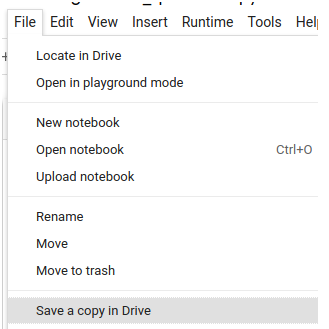

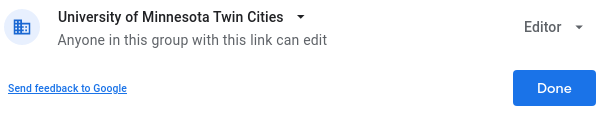


# References

- chatgpt - syntax for sorting based on the value of the items in dictionary and extracting just the keys as list - gave me the lambda function syntax that i used
- chatpgt - Syntax for assigning normal distribution for a row in python - gave me the syntax with standard deviation as well, which I used in SVD


Task# Part 0 -- Provided code

You should be aware of what's here. It's recommended that you at least skim this before you get started and take some notes further down the file about where each provided function is used in provided code, or will need to be used by your code.

## Imports


In [1]:
!pip install git+https://github.com/NicolasHug/Surprise.git@fixnp2
# install surprise -- this takes a minute or so... we might not end up using this framework very much, but it's nice to have a _reall_ tookit

  Cloning https://github.com/NicolasHug/Surprise.git (to revision fixnp2) to /tmp/pip-req-build-hv92lrav
  Running command git clone --filter=blob:none --quiet https://github.com/NicolasHug/Surprise.git /tmp/pip-req-build-hv92lrav
  Running command git checkout -b fixnp2 --track origin/fixnp2
  Switched to a new branch 'fixnp2'
  Branch 'fixnp2' set up to track remote branch 'fixnp2' from 'origin'.
  Resolved https://github.com/NicolasHug/Surprise.git to commit 935a0ea7609ee10897c5d9c6de9ed18df5fdcd93
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2556281 sha256=1052dfefaef88712671bf420904fd2e25add5631395bdc6d8950a11e03e8be5a
  Stored in directory: /tmp/pip-ephem-wheel-cache-suk50hkg/wheels/68/ab/41/537c53abc220a1fb4a11000e7272d0478452b472e9f3a9359d
Successfully built scikit-surprise


In [2]:
!# Feel free to add more imports here as needed
import random
import numpy as np
from surprise import AlgoBase
from tqdm import tqdm

from surprise import Dataset, BaselineOnly, KNNBasic, NMF, SVD, accuracy,Reader
from surprise.model_selection import KFold
from tqdm.auto import tqdm

from sklearn.metrics import ndcg_score
import pandas as pd


my_seed = 2025
random.seed(my_seed)
np.random.seed(my_seed)

In [3]:
# Load Rating Data and make sure it's formatted in useful ways
import matplotlib.pyplot as plt
from surprise import Reader
from surprise.utils import get_rng
from collections import defaultdict

# We'll use MovieLens 100K for the recommendation experiment.
ratings_data = Dataset.load_builtin('ml-100k', prompt=False)

ratings_df = pd.DataFrame(
    ratings_data.raw_ratings,
    columns=["userId", "movieId", "rating", "timestamp"]
)[["userId", "movieId", "rating"]]

ratings_df["userId"] = ratings_df["userId"].astype(str)
ratings_df["movieId"] = ratings_df["movieId"].astype(str)
ratings_df["rating"] = ratings_df["rating"].astype(float)

display(ratings_df.head())
print("Number of ratings:", len(ratings_df))
print("Number of users:", ratings_df["userId"].nunique())
print("Number of movies:", ratings_df["movieId"].nunique())


Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /root/.surprise_data/ml-100k


,userId,movieId,rating
0,196,242,3.0
1,186,302,3.0
2,22,377,1.0
3,244,51,2.0
4,166,346,1.0


Number of ratings: 100000
Number of users: 943
Number of movies: 1682


### Content Based Similarty Function


In [4]:
# This cell gets a dataframe that is movieId x tagId with the dataframe values being a "relivance" score.
# If you wish to read more about this "tag genome" you can read about the dataset here: https://files.grouplens.org/datasets/tag-genome/README.html (which also has a link to the original paper.)
# The basic idea though is that each tag is a labeled feature like "Funny", or "Animals", or "Ninja". Each score says how relivant that label is to this movie.
# We can use similarity according to this matrix as a stand-in for a content-based similarity between movies.

# Note -- this is by tag_id not raw tag name
# whose entries (i,j) represent the relevance between movie i and tag j.
url = 'https://drive.google.com/file/d/1eATlHqQKzAocs03Woxm4Bq8bJ-yeBLxa/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id=' + url.split('/')[-2]
movie_tags = pd.read_csv(path, index_col=0)
movie_tags.index = movie_tags.index.map(int).map(str) #the index of movie_tags has type str
display(movie_tags)

,15,46,60,89,125,149,151,188,205,230,...,901,937,949,951,952,956,1044,1063,1064,1067
movieId,,,,,,,,,,,,,,,,,,,,,
2,0.031,0.006,0.021,0.030,0.030,0.053,0.036,0.028,0.025,0.148,...,0.077,0.009,0.198,0.030,0.102,0.038,0.092,0.193,0.110,0.042
3,0.018,0.006,0.007,0.078,0.042,0.044,0.026,0.026,0.028,0.183,...,0.023,0.013,0.232,0.052,0.056,0.018,0.335,0.653,0.048,0.016
4,0.039,0.017,0.030,0.025,0.079,0.038,0.245,0.060,0.013,0.176,...,0.081,0.010,0.088,0.036,0.100,0.010,0.255,0.322,0.073,0.023
5,0.030,0.005,0.026,0.018,0.025,0.035,0.061,0.017,0.020,0.044,...,0.065,0.005,0.092,0.025,0.108,0.009,0.259,0.311,0.116,0.032
6,0.080,0.049,0.014,0.086,0.060,0.048,0.038,0.097,0.021,0.075,...,0.024,0.043,0.121,0.015,0.027,0.010,0.162,0.478,0.216,0.023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1664,0.031,0.006,0.013,0.033,0.038,0.025,0.030,0.025,0.023,0.289,...,0.037,0.009,0.118,0.062,0.047,0.017,0.069,0.224,0.102,0.046
1674,0.066,0.086,0.011,0.032,0.016,0.006,0.028,0.338,0.019,0.042,...,0.030,0.019,0.092,0.033,0.009,0.008,0.025,0.624,0.042,0.062
1675,0.147,0.016,0.007,0.598,0.018,0.032,0.025,0.046,0.023,0.034,...,0.026,0.008,0.190,0.017,0.309,0.027,0.204,0.145,0.137,0.005


In [5]:
# A provided function for computing the similarity between two movies (by movie Id) According to the tag genome.
# NOTE -- it returns 0 if a movie is unknown. you may wish to deliberately raise an error instead if you're running into issues and want to check if the ids are lining up right.
from scipy.stats import pearsonr
def safe_tag_similarity(movie_a, movie_b):

    movie_a = str(movie_a)
    movie_b = str(movie_b)

    if movie_a not in movie_tags.index or movie_b not in movie_tags.index:
        return 0.0

    movie_a_vals = movie_tags.loc[movie_a].values
    movie_b_vals = movie_tags.loc[movie_b].values

    corr, _ = pearsonr(movie_a_vals, movie_b_vals)

    return corr

# Quick test -- the similarity should be in the 0.54 space.
sim = safe_tag_similarity(2, 3)
print("The similarity between movieId 2 and movieId 3 is", sim)

# You are STRONGLY encouraged to try out a few other movie parts below.

The similarity between movieId 2 and movieId 3 is 0.5434300977081341


## Additions to the Surprise Framework
 * User-based crossfolder
 * Top-N Recommendation object (which we will use as a base class for future recommendation algorithms)


In [6]:
# A surprise cross-validation iterator for user-based crossvalidation.
# The existing crossvalidation solutions only support rating-based crossvalidation
# The experiment we will do, however, makes the most sense crossvalidating by user
# This would be used similarly to the example here: https://surprise.readthedocs.io/en/stable/getting_started.html#use-cross-validation-iterators
#   WITH ONE IMPORTANT NOTE -- this iterator also returns a list of the test set users
#   for trainset, testset, test_users in kf.split(data):
# Additional useful information, test_users and testset data are all in raw-form. Only the trainset will be simplified to internal_ids.
# Largely this won't create problems for you, simply use the data understanding that internal ids largely live only inside algorithm implementations.

import numbers
from collections import defaultdict
from itertools import chain
from math import ceil, floor

import numpy as np

from surprise.utils import get_rng


class UserKFold:
    """A user-based cross-validation iterator (based on: https://github.com/NicolasHug/Surprise/blob/master/surprise/model_selection/split.py#L53)

    Each user is put into one of the k folds.
    Each fold is used to make the test set once, with the remaining k-1 folds
    uses being used for training.
    The test-fold users will have a fixed percent of their ratings witheld for
    testing, the rest will be used for training.

    Args:
        n_splits(int): The number of folds.
        holdout_perent(float): the percent of a test user's ratings to hold out
            in the test set.
        random_state(int, RandomState instance from numpy, or ``None``):
            Determines the RNG that will be used for determining the folds. If
            int, ``random_state`` will be used as a seed for a new RNG. This is
            useful to get the same splits over multiple calls to ``split()``.
            If RandomState instance, this same instance is used as RNG. If
            ``None``, the current RNG from numpy is used. ``random_state`` is
            only used if ``shuffle`` is ``True``.  Default is ``None``.
        shuffle(bool): Whether to shuffle the ratings in the ``data`` parameter
            of the ``split()`` method. Shuffling is not done in-place. Default
            is ``True``.
    """

    def __init__(self, n_splits=5, holdout_percent = 0.2, random_state=None, shuffle=True):

        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state
        self.holdout_percent = holdout_percent

    #Note: This won't be as efficient as the built-in splits.
    def split(self, data):
        """Generator function to iterate over trainsets and testsets.

        Args:
            data(:obj:`Dataset<surprise.dataset.Dataset>`): The data containing
                ratings that will be divided into trainsets and testsets.

        Yields:
            tuple of (trainset, testset, test_users)
        """

        # Step 1: re-org by user
        ratings_per_user = defaultdict(list)
        for rating in list(data.raw_ratings):
          # format is uid, iid, rating, optional timestamp
          ratings_per_user[rating[0]].append(rating)

        if self.n_splits > len(ratings_per_user) or self.n_splits < 2:
            raise ValueError(
                "Incorrect value for n_splits={}. "
                "Must be >=2 and less than the number "
                "of ussers".format(len(ratings_per_user))
            )

        users = list(ratings_per_user.keys())
        if self.shuffle:
            rng = get_rng(self.random_state)
            rng.shuffle(users)
            for user_rating_list in ratings_per_user.values():
                rng.shuffle(user_rating_list)

        # assign to folds.
        folds = []
        start, stop = 0, 0
        for fold_i in range(self.n_splits):
            start = stop
            stop += len(users) // self.n_splits
            if fold_i < len(users) % self.n_splits:
                stop += 1
            folds.append(users[start:stop])

        # now generate datasets
        for fold_i in range(self.n_splits):
            raw_trainset = []
            # add all ratings from non-test users.
            for i in range(self.n_splits):
                if i != fold_i:
                  for user in folds[i]:
                    raw_trainset.extend(ratings_per_user[user])
            raw_testset = []
            # process testing users for this fold
            for user in folds[fold_i]:
                split_point = max(1, int(len(ratings_per_user[user]) * self.holdout_percent))
                raw_testset.extend(ratings_per_user[user][:split_point])
                raw_trainset.extend(ratings_per_user[user][split_point:])
            # make the objects and send them out.
            trainset = data.construct_trainset(raw_trainset)
            testset = data.construct_testset(raw_testset)
            test_users = list(folds[fold_i])

            yield trainset, testset, test_users

    def get_n_folds(self):
        return self.n_splits

In [7]:
# A helper function for using test sets which I found important.
def get_test_set_items(testset, user_id):
  """Get the items a user has rated in a test set"""

  retval = []
  # test sets are just lists of (user, item, rating) -- not a real class
  for uid, iid, rating in testset:
    if uid == user_id:
      retval.append(iid)
  return retval



In [8]:
# Additionally, Surprise doesn't have a concept for a "recommender" at all.
# No problem, we can add a new concept to the framework. This and it's subclasses
# Take a scoring algorithm and produce outputs.
# You use them from the two provided functions here: fit and recommend_external_id
# Although when implementing you would probably want to override recommend_internal_id instead.
# (The difference of course is just the ID domain -- internal is preferred for algorithm building, external is preferred when using the algorithm)
from surprise import PredictionImpossible

class TopNRecommender():
    def __init__(self, base_predictor):
          self.base_predictor = base_predictor
    def fit(self, trainset):
          self.base_predictor.fit(trainset)
          self.trainset = trainset
    def recommend_internal_id(self, uid, n_items, candidate_item_ids = None, exclude_item_ids=None):
        """Recommend based on / using internal ids.
        Takes an internal user Id and a number of items to recommend and returns
        Internal a list of internal item ids.
        Unless candidate and exclude item ids are set -- this may return any
        item_id known  to the system which does not currently have a rating by
        this user.
        This may return fewer than n_items if not enough items can be recommended

        Args:
            uid(int): an internal user id.
            n_items(int): an int indicating how many items to recommend.
                Set to -1 for all items (probably. I didn't test that.)
            candidate_item_ids: a list/set/etc. of internal item_ids for
                recommending. If not passed this will defaul to all items
            exclude_item_ids: a list/set/etc. of internal item_ids to not
                recommend (even if those items are provided in candidate set)
                If not given it will default to all items the user rated in the
                training set.
        NOTE: the need for explicitly candidate set and exclude item sets is common in production systems so I included it here for completeness.
        The defaults I assigned should be suitable for the evaluation at hand -- so you likely won't need to set those explicitly.
        """
        # returns a list of n internal item ids
        # excludes the exclude_items -- if not passed this defaults to all items the user has rated

        if exclude_item_ids is None and uid in self.trainset.ur:
            exclude_item_ids = {j for (j, _) in self.trainset.ur[uid]}
        elif exclude_item_ids is None:
            exclude_item_ids = set()
        if candidate_item_ids is None:
          candidate_item_ids = list(self.trainset.all_items())

        all_preds = []
        for iid in candidate_item_ids:
            if iid not in exclude_item_ids:
                try:
                  score = self.base_predictor.estimate(uid, iid)
                  if isinstance(score, tuple):
                    score = score[0]
                except PredictionImpossible:
                  continue
                all_preds.append((score, iid)) # store as prediction, item
        all_preds.sort(reverse=True) # since we stored prediction first this will sort by prediciton
        return [x[1] for x in all_preds[:n_items]]

    def recommend_external_id(
        self,
        raw_uid,
        n_items=10,
        candidate_item_ids=None,
        exclude_item_ids=None,
    ):
        try:
            uid = self.trainset.to_inner_uid(str(raw_uid))
        except ValueError:
            return []

        if candidate_item_ids is not None:
            candidate_item_ids = [
                self.trainset.to_inner_iid(str(iid))
                for iid in candidate_item_ids
                if str(iid) in self.trainset._raw2inner_id_items
            ]

        if exclude_item_ids is not None:
            exclude_item_ids = {
                self.trainset.to_inner_iid(str(iid))
                for iid in exclude_item_ids
                if str(iid) in self.trainset._raw2inner_id_items
            }

        inner_recs = self.recommend_internal_id(
            uid=uid,
            n_items=n_items,
            candidate_item_ids=candidate_item_ids,
            exclude_item_ids=exclude_item_ids,
        )

        return [str(self.trainset.to_raw_iid(iid)) for iid in inner_recs]

# Task 1 Building Metrics
The surprise library has a scandalously small set of metrics built in. (In it's defense, it's not super-hard to use external metrics.) To help augment this we will be building two new metrics.*italicized text*


## Task 1.1 ILS

In this task, we will implement ILS based on tag genome (https://files.grouplens.org/datasets/tag-genome/README.html). The tag genome encodes how strongly movies exhibit particular properties represented by tags (atmospheric, thought-provoking, realistic, etc.). The tag genome was computed using a machine learning algorithm on user-contributed content including tags, ratings, and textual reviews.

Intra-list Similarity: ILS is a diversity metric. If you recommend a list L of recommendations ($item_1,...,item_n$) to a user, the ILS of this list is defined as $ILS(L) = \frac{1}{|L|\times(|L|-1)/2}\sum_{i\neq j, i,j\in L}Similarity(item_i,item_j)$. For this function we will assume that the end-user passes in a function that defines "similarity" for us. In practice this will just be the `safe_tag_similarity` function above -- but for now please code a re-usable and generic ILS function.

Your function should take a single list of item ids (external not internal) and return the ILS score


In [9]:
def intra_similarity(item_list, sim_function):
    """
    Calculates the intra-similarity score from a list of items

    Parameters:
    item_list -- a recommendation list of items. Should be external IDs
    sum_function -- the similarity function to use.
    float in [-1, 1.]: The averaged similarity between each pair of items in the recommendation list
    """
    n = len(item_list)
    sim_sum = 0

    for i in range(n):
        for j in range(i + 1, n):
            sim_sum += sim_function(item_list[i], item_list[j])

    return sim_sum / (n*(n-1)/2)


In [10]:
# Questions / Tests of correctness.

# What is the ILS of a recommendation for movies 1 through 10 (largely random movies)
first_10_movies = [str(i) for i in range(1, 11)]
first_10 = intra_similarity(first_10_movies, safe_tag_similarity)
print("Movies 1 to 10:", first_10)

# What is the ILS of the list of items [449, 228, 229, 230, 450, 227, 380, 222] (The 8 star-trek movies old enough to be in ML-100K)
star_trek_movies = [str(i) for i in [449, 228, 229, 230, 450, 227, 380, 222]]
star_trek = intra_similarity(star_trek_movies, safe_tag_similarity)
print("Star Trek:", star_trek)


Movies 1 to 10: 0.3717002836175849
Star Trek: 0.6444936243496372


## Task 1.2 Precision

In this task, we will implement the Precision metric. This is defined as a relationship between recommended items $L$ and "good" items $G$: $\frac{|L \cap G|}{|L|}$ (strictly this is normally defined against the true positive rate and false positive rate -- but this defintion is equivalent)

Your function should take two lists of item ids (external not internal) The first representing recommended items, the second representing those that are "good" for this user.


In [11]:
def precision(item_list, good_items):

    item_set = set(item_list)
    good_set = set(good_items)

    return len(item_set.intersection(good_set)) / len(item_set)

# Calculate Precision
item_list = [1,2,3,4,5]
good_items = [2,4,6]
precision_score = precision(item_list, good_items)
print("Precision:", precision_score)


Precision: 0.4


We are not requiring test for this one since it's pretty simple. You may choose to test it on your own (and are in-fact recommended to do so). The best way to test this will be to pass in hand-crafted lists such as `[1,2,3,4,5]` and `[2,4,6]` and manually compute the expected precision ($\frac{2}{5} = 0.4$ in this case)


# Task 2: Diversification algorithm

Ziegler et al. argues that a recommendation list can be **accurate but still boring**.
For example, if a user likes one genre, a recommender may fill the whole top-10 with very similar movies.
This is often described as a **portfolio effect**: each item may look good on its own, but the **list as a whole** may not be well-balanced.

So instead of treating recommendations as isolated items, this section evaluates and reranks the **recommendation list as a set**.

Zeigler et al. resolve this with the sequential diversification algorithm. This algorithm works on top of another pre-made recommendation list (typically the top-N recommendation of an underlying prediction algorithm) and re-orders items to make a shorter, more diverse list. The general pseudocode can be found below:

1. To make a size N recommendation, take a larger list from underlying algorithm (for example, for a top-10 ziegler recommenders a top-50 list from the predictor)
2. Prepare an output list of items
3. Add the first-item (top-prediction) from the original list to the output list.
4. Compute the **rank** for each item in the input list. The top-item has rank 1, the next rank 2 and so-forth.
5. Repeatedly pick the next movie to output as follows:
    1. For each item not already chosen to recommend compute it's similarity with each item already chosen to recommend
    2. Sort the not-yet-chosen items by their average similarity with the already-chosen-to-recommend items.
    3. compute a "similarity rank" for each not-yet-chosen item. The item with the lowest average similarity should have rank 1, the next lowest rank 2 etc.
    4. Pick the item with the lowest $(1-theta_f)*prediction\_rank + theta_f*similarity\_rank$
    5. Add this item to the output list, and remove it from your tracking of not-yet-chosen-items.
6. Repeat the above process until the output list hits the target size.

In this algorithm `theta_f` controls the tradeoff between the original (prediction) ranking, and the diversity ranking with larger values indicating a storng diversification factor:

- `0.0` = stay close to the original ranking
- `0.5` = medium diversification
- `0.9` = stronger diversification


In [12]:
class DiversifiedRecommender(TopNRecommender):
    def __init__(self, base_predictor, theta_f, initial_N=75, sim_function=safe_tag_similarity):
      """ base_predictor -- the underliying predictor algorithm
      theta_f -- the strength of the tradeoff, between 0 and 1.
      initial_N -- the number of top-N items to get from the predictor in the first place.
      sim_function -- the function to use when computing a similarity.
        !! use this don't directly call the movie similarity function (or else your code will only work with movies!!)
      """
      super().__init__(base_predictor)
      self.theta_f = theta_f
      self.initial_N = initial_N
      self.sim_function = sim_function

    def recommend_internal_id(self, uid, n_items, candidate_item_ids = None, exclude_item_ids=None):
        """Recommend based on / using internal ids.
        Takes an internal user Id and a number of items to recommend and returns
        Internal a list of internal item ids.
        Unless candidate and exclude item ids are set -- this may return any
        item_id known  to the system which does not currently have a rating by
        this user.
        This may return fewer than n_items if not enough items can be recommended

        Args:
            uid(int): an internal user id.
            n_items(int): an int indicating how many items to recommend.
                Set to -1 for all items (probably. I didn't test that.)
            candidate_item_ids: a list/set/etc. of internal item_ids for
                recommending. If not passed this will defaul to all items
            exclude_item_ids: a list/set/etc. of internal item_ids to not
                recommend (even if those items are provided in candidate set)
                If not given it will default to all items the user rated in the
                training set.
        """

        # Step 1: get a top-N list. we can use base code for this.
        original_top_n = super().recommend_internal_id(uid, self.initial_N, candidate_item_ids, exclude_item_ids)

        # Step 2: Set up data for the algorithm -- we recommend storing :
        #         A dictionary from movie_id to prediction rank
        #         A list where we will store the chosen items
        #         And a ist of remaining items.

        n_items = min(n_items, len(original_top_n))
        prediction_rank = {iid: rank + 1 for rank, iid in enumerate(original_top_n)}
        chosen_items = [original_top_n[0]]
        remaining_items = list(original_top_n[1:])

        # Step 3: Repeatedly pick the item that balances diversity and prediction ranks per above pseudocode
        while len(chosen_items) < n_items and remaining_items:

            # average similarity of each remaining item to chosen items
            avg_similarities = {}
            for iid in remaining_items:
                raw_iid = self.trainset.to_raw_iid(iid)
                sim_total = 0.0

                for chosen_iid in chosen_items:
                    raw_chosen_iid = self.trainset.to_raw_iid(chosen_iid)
                    sim_total += self.sim_function(raw_iid, raw_chosen_iid)

                avg_similarities[iid] = sim_total / len(chosen_items)

            sim_rank_items = sorted(remaining_items, key=lambda iid: avg_similarities[iid])
            similarity_rank = {iid: rank + 1 for rank, iid in enumerate(sim_rank_items)}

            # find next best item
            best_item = None
            best_score = float("inf")

            for iid in remaining_items:
                score = (
                    (1 - self.theta_f) * prediction_rank[iid]
                    + self.theta_f * similarity_rank[iid]
                )

                if score < best_score:
                    best_score = score
                    best_item = iid

            # update the lists
            chosen_items.append(best_item)
            remaining_items.remove(best_item)

        return chosen_items

# Task 3: Code Ziegler's Evaluation

Ziegler et al. had an evaluation in which User-User and Item-Item was used as a base algorithm for diversification with a range of diversification factors from 0 to 0.9. For each diversification factor strength they created a train-test split and then for each user created a top-10 _book_ list. Then for each user they computed:

1. Precision (in their formulation all ratings were implicit -- so anything that was rated was a "Good item")
2. Recall
3. ILS (They had a fancy taxonomy-based similarity metric which we can't easily replicate)
4. The overlap between the recommended item list, and the original top-10 list.

We will need to simplify this, and change some details to fit in our MovieLens domain. We will:

* Run a 5-fold user-based crossvalidation, for each train and test set...
  * For each base predictor...
      * For each theta value...
          * Train the base predictor on the training set
          * Build a diversifying recommener with the given base predictor and theta value
          * For each test user...
            * Create a 15-item recommendation list
            * Compute the ILS for this list
            * Compute the Precision of this list (using the test-set items as the "good" items)
            * Store the results for this user/algorithm/diversity tuple

This will then output a dataframe where each row represents one test-user on one algorithm configuration. so you'll have columns such as:

1. Base Algorithm name
2. Theta Value
3. Diversity Score
4. Precision Score
5. (other fields you want to return such as userId or fold number)

To make this a bit more re-usable we've created a template for this function. This might not be how **you** would initially plan this function out, but we promise it ends up being a decent way to do this. (This also allowed us to give you some starter code to simplify how often you need to read code above)


In [13]:
def run_ziegler_experiment(
    theta_values, #list of floats
    predictors #dictionary going from name to AlgoBase instances {name: AlgoBase objects}
):
    """
    Run one simplified Ziegler-style experiment
    """
    # set up a UserKFold -- default values should be fine.
    splitter = UserKFold()
    crossfolds = list(splitter.split(ratings_data))
    #FOR TESTING YOU CAN UNCOMMENT THE FOLLOWING TO RUN AN ABREVIATED VERSION OF THE TEST USING ONLY 1 FOLD
    # crossfolds = crossfolds[:1]

    # setup storage to store results.
    results = []

    for trainset, testset, test_users in tqdm(crossfolds):
        for theta in theta_values:
            for name, algo_base in predictors.items():

                # 1. Create a diversified recommender for the given algorithm and theta
                #     use the default initial_N and similarity function values -- we set them appropriately in advance
                #     Then train the recommender and predictor
                rec = DiversifiedRecommender(
                    base_predictor=algo_base,
                    theta_f=theta
                )
                rec.fit(trainset)

                # 2. Get a top-15 recommendation list for each test users.
                #     Then compute the precision and ILS values using your earlier metrics
                for raw_uid in test_users:
                    recommended_items = rec.recommend_external_id(raw_uid, n_items=15)

                    # items in test set
                    good_items = get_test_set_items(testset, raw_uid)

                    diversity_score = intra_similarity(recommended_items, rec.sim_function)
                    precision_score = precision(recommended_items, good_items)

                # 3. Store the results in your results list.
                #     one example how this might look in code:
                #     results.append({"algo":name, "theta":theta,"diversity":diversity, "precision":pcs})

                    results.append({
                        "userId": raw_uid,
                        "algo": name,
                        "theta": theta,
                        "diversity": diversity_score,
                        "precision": precision_score
                        })

    # convert the result into a pandas frame and return it
    return pd.DataFrame(results)




In [15]:

# Example usage:
theta_values = [0.0, 0.3, 0.6, 0.9]

# This creates an Item-Item algorithm with default settings in Surprise
ItemItem = KNNBasic(sim_options={
    "name": "cosine",
    "user_based": False,  # compute  similarities between items
    "min_support":1,
})

ziegler_results = run_ziegler_experiment(theta_values, {"II":ItemItem})
display(ziegler_results)


  0%|          | 0/5 [00:00<?, ?it/s]

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing th

,userId,algo,theta,diversity,precision
0,567,II,0.0,0.433978,0.000000
1,11,II,0.0,0.310433,0.133333
2,896,II,0.0,0.258040,0.266667
3,720,II,0.0,0.101033,0.000000
4,224,II,0.0,0.334922,0.000000
...,...,...,...,...,...
3767,514,II,0.9,0.000000,0.000000
3768,583,II,0.9,0.000000,0.000000
3769,864,II,0.9,0.000000,0.066667
3770,737,II,0.9,0.000000,0.000000


In [16]:
avg_results = (
    ziegler_results
    .groupby("theta")[["precision", "diversity"]]
    .mean()
    .reset_index()
)

display(avg_results)

,theta,precision,diversity
0,0.0,0.042842,0.182866
1,0.3,0.038247,0.075225
2,0.6,0.031884,0.028158
3,0.9,0.026723,0.007554


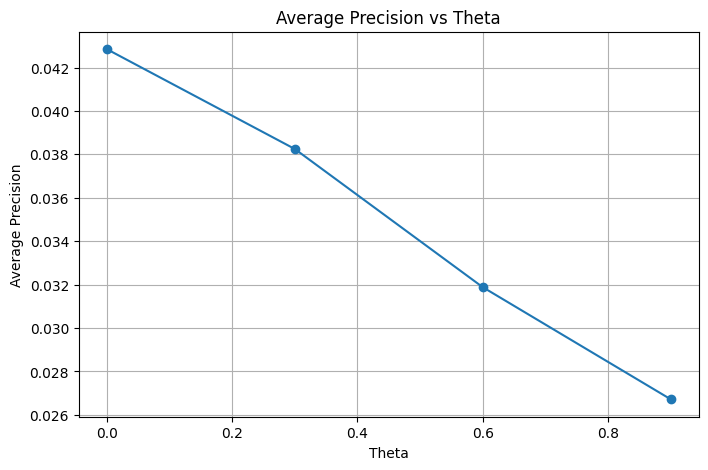

In [17]:
#TODO: plot average precision against theta

plt.figure(figsize=(8, 5))
plt.plot(avg_results["theta"], avg_results["precision"], marker="o")
plt.xlabel("Theta")
plt.ylabel("Average Precision")
plt.title("Average Precision vs Theta")
plt.grid(True)
plt.show()

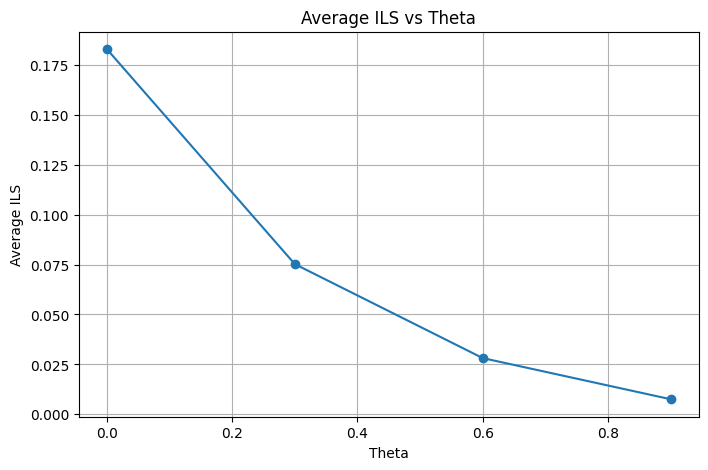

In [18]:
#TODO: plot average ILS against theta

plt.figure(figsize=(8, 5))
plt.plot(avg_results["theta"], avg_results["diversity"], marker="o")
plt.xlabel("Theta")
plt.ylabel("Average ILS")
plt.title("Average ILS vs Theta")
plt.grid(True)
plt.show()

In [19]:
#TODO -- does this generally look like the figures in Ziegler's original paper for item-item?
'''
1. For precision vs theta: the figure looks like ziegler's original paper for item item. Where we had decreasing precision for increasing theta.
2. For ILS vs theta: the figure looks like ziegler's original paper for item item. Where we had decreasing curve for ILS for increasing theta.
'''


# Task 4: Funk's SVD

We've implemented several algorithms already, but we've not done a gradient descent algorithm yet. As these are the most popular family right now -- I figured we should build one by hand to make sure we understand them!

For this step, you should implement the funk svd algorithm https://sifter.org/simon/journal/20061211.html (especially the part starting from "So, yeah, you mathy guys are rolling your eyes right now as it dawns on you how short the path was.")

For this coding task I'm having us directly code into the Surprise frameworks algorithm object, this will let you use the surprise framework training and tuning code if you wish.

The provided code has a few parameters set already:

* `n_epochs` how many times to loop over the entire training set of ratings when training a feature.
* `k` how many features to use
* `learning_rate` and `gamma` the standard gradient descent parameters $\alpha$ and $\lambda$ in the slides respectively.

Default values for these are set in the constructor, but you can easily override them.

Remember, the basic algorithm for funk's SVD has the following structure:

1. Initalize storage for all model parameters:
    * P (stores user features) a |U| x k matrix.
    * Q (stores item features) a |I| x k matrix.
    * Initalize these matrixes to zero.
2. For each feature f (1 .. k):
    1. Initalize the user and item feature f to random values.
    1. For each epoch (1 .. n_epoch):
        1. For each user, movie, rating pair with an observed rating
            1. Compute the prediction based on the current state of $P_u$ and $Q_i$.
            2. Compute the prediction error (rating - pred)
            3. Compute the updates to each feature (make sure these are computed _atomically_ -- I.E. don't use the updated userFeature when computing the update for the movieFeature.)
                * userFeature[user, f] += learning_rate * (error * movieFeature[f, movie] - gamma*userFeature[user, f]);
                * movieFeature[f, movie] += learning_rate * (error * userFeature[user, f] - gamma* movieFeature[f, movie]);

You will also need to make the prediction function which should:

1. Check if the user and item given are part of the training data
2. if not, return NaN or 0
3. if yes: return $P_u \cdot Q_i$


In [23]:
class MyFunkSVD(AlgoBase):
    def __init__(self, k=10, learningRate = 0.005, damping = 0.02, nEpoch = 20):
        AlgoBase.__init__(self)
        self.k=k
        self.learningRate = learningRate
        self.damping = damping
        self.nEpock = nEpoch
        self.rating_df = None # this gets set in `fit`
        self.rating_matrix = None # this gets set in `fit`
        self.user_feature = None
        self.movie_feature = None

    def fit(self, trainset):
        # trainset: training dataset, https://surprise.readthedocs.io/en/stable/trainset.html?highlight=trainset

        self.rating_df = pd.DataFrame([x for x in trainset.all_ratings()],
                                   columns=["userId", "movieId", "ratings"])
        self.rating_matrix = self.rating_df.pivot(index='userId', columns='movieId', values='ratings')
        self.rating_matrix.index = self.rating_matrix.index.map(str)# get the list of userId (type str)
        self.rating_matrix.columns = self.rating_matrix.columns.map(str)# get the list of movieId (type str)
        self.predict_ratings = pd.DataFrame(index=self.rating_matrix.index, columns=self.rating_matrix.columns)

        ratings = self.rating_matrix.values
        n_users = ratings.shape[0]
        n_movies = ratings.shape[1]
        # here we initialize the P and Q matrixes (you can change the chosen names)
        # you will need to optimize the entries of these 2 matrices in your funksvd algorithm
        self.user_feature = np.zeros((n_users, self.k))
        self.movie_feature = np.zeros((self.k, n_movies))

        AlgoBase.fit(self, trainset)

        for f in range(self.k):
            self.user_feature[:, f] = np.random.normal(scale=0.1, size=n_users)
            self.movie_feature[f, :] = np.random.normal(scale=0.1, size=n_movies)

            for epoch in range(self.nEpock):
                for user, movie, rating in trainset.all_ratings():
                    pred = np.dot(self.user_feature[user, :f+1], self.movie_feature[:f+1, movie])
                    error = rating - pred

                    old_user_f = self.user_feature[user, f]
                    old_movie_f = self.movie_feature[f, movie]

                    self.user_feature[user, f] += self.learningRate * (
                        error * old_movie_f - self.damping * old_user_f
                    )
                    self.movie_feature[f, movie] += self.learningRate * (
                        error * old_user_f - self.damping * old_movie_f
                    )

        return self


    def estimate(self, user, item):
        # This should compute an actual prediction for user, item
        # You should make a point to check if the user and item are part of your feature vector/training matrix
        # due to random splitting you may be asked to do the impossible -- predict an item you did not train for.
        if not self.trainset.knows_user(user) or not self.trainset.knows_item(item):
            return float("nan")

        return np.dot(self.user_feature[user], self.movie_feature[:, item])




In [24]:
# TODO: Test your implementation.
# Using MovieLens 100K -- run a standard 5-fold crossvalidation evaluation to compute the RMSE of your algorithm.
# Your code should look similar to https://surprise.readthedocs.io/en/stable/getting_started.html#use-cross-validation-iterators
# Although you'll need to make a few adjustments. Notably, I only want a single RMSE at the end.

data = Dataset.load_builtin("ml-100k")

kf = KFold(n_splits=5)

rmse_scores = []
algo = MyFunkSVD()

for trainset, testset in kf.split(data):

    algo.fit(trainset)
    predictions = algo.test(testset)
    fold_rmse = accuracy.rmse(predictions, verbose=False)
    rmse_scores.append(fold_rmse)

final_rmse = np.mean(rmse_scores)
print("Final average RMSE:", final_rmse)

Final average RMSE: 0.9608635095025961


# Task 5: The final replication

Run ziegler's experiment with Item-Item and your version of the SVD algorithm. Produce plots of precision and recall against theta_f values. At a minimum use values [0, 0.3, 0.6, 0.9] You are encouraged to use a more desnse grid if you have time.


In [25]:
def recall(recommended_items, good_items):
    good_items = set(good_items)
    if len(good_items) == 0:
        return 0.0
    return len(set(recommended_items) & good_items) / len(good_items)

In [29]:
# Code here

def run_zeigler_final(theta_values, predictors):
    splitter = UserKFold()
    crossfolds = list(splitter.split(ratings_data))

    results = []

    for trainset, testset, test_users in tqdm(crossfolds):

        for name, algo in predictors.items():
            algo.fit(trainset)

            for theta in theta_values:
                rec = DiversifiedRecommender(base_predictor=algo, theta_f=theta)
                rec.trainset = trainset

                for raw_uid in test_users:
                    recommended_items = rec.recommend_external_id(raw_uid, n_items=15)
                    good_items = get_test_set_items(testset, raw_uid)

                    results.append({
                        "userId": raw_uid,
                        "algo": name,
                        "theta": theta,
                        "precision": precision(recommended_items, good_items),
                        "recall": recall(recommended_items, good_items)
                    })

    return pd.DataFrame(results)

In [30]:
predictors = {
    "Item-Item": KNNBasic(sim_options={'name': 'cosine', 'user_based': False, "min_support":1,}),
    "FunkSVD": MyFunkSVD(k=10, learningRate=0.005, damping=0.02, nEpoch=20)
}
theta_values = [0.0, 0.3, 0.6, 0.9]

results = run_zeigler_final(theta_values, predictors)
display(results)

  0%|          | 0/5 [00:00<?, ?it/s]

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.


,userId,algo,theta,precision,recall
0,775,Item-Item,0.0,0.000000,0.000000
1,164,Item-Item,0.0,0.000000,0.000000
2,647,Item-Item,0.0,0.000000,0.000000
3,482,Item-Item,0.0,0.000000,0.000000
4,136,Item-Item,0.0,0.000000,0.000000
...,...,...,...,...,...
7539,354,FunkSVD,0.9,0.200000,0.065217
7540,892,FunkSVD,0.9,0.133333,0.044444
7541,904,FunkSVD,0.9,0.000000,0.000000
7542,147,FunkSVD,0.9,0.000000,0.000000


In [31]:
results_df = results.groupby(["algo", "theta"]).mean(numeric_only=True).reset_index()

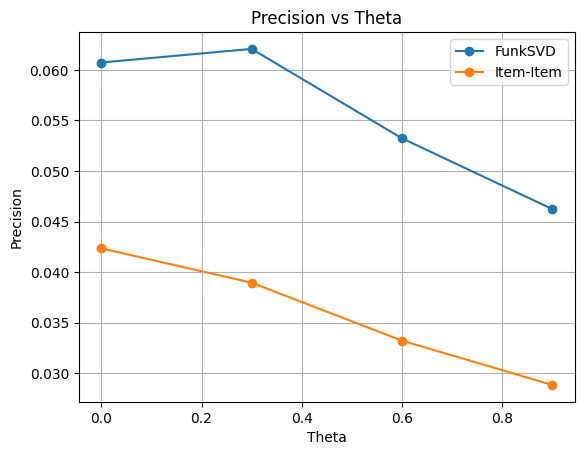

In [32]:
plt.figure()

for algo in results_df["algo"].unique():
    subset = results_df[results_df["algo"] == algo]
    plt.plot(subset["theta"], subset["precision"], marker='o', label=algo)

plt.xlabel("Theta")
plt.ylabel("Precision")
plt.title("Precision vs Theta")
plt.legend()
plt.grid()
plt.show()

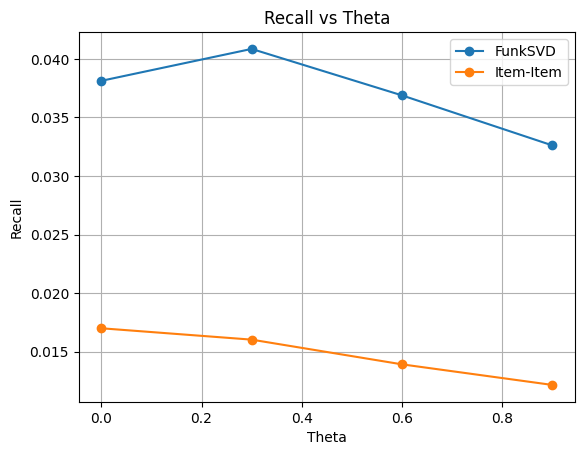

In [33]:
plt.figure()

for algo in results_df["algo"].unique():
    subset = results_df[results_df["algo"] == algo]
    plt.plot(subset["theta"], subset["recall"], marker='o', label=algo)

plt.xlabel("Theta")
plt.ylabel("Recall")
plt.title("Recall vs Theta")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Questions:

# How (if at all) do the SVD results differ from the Item-Item Results?

'''
ANS:

The SVD results differ from the Item-Item results in the following ways:
1. SVD achieved higher recall and precision than item-item for every theta
2. SVD's precision and recall increases when theta is 0.3 and then drops again, where item-item declines steadily.


'''